In [15]:
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import tensorflow as tf
from datetime import timedelta
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [16]:
#data loading
df = pd.read_csv("C:/Infosys_smp/SHARE_MARKET_PREDICTION/dataset.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)
data = df[["close"]].values
#h5
lstm_model = load_model("lstm_close_model.h5", compile=False)
scaler = joblib.load("lstm_scaler.pkl")

In [17]:
#scaling (MinMaxScaler-to scale data between 0 and 1)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [18]:
#creating sequence
def create_sequences(data, n_steps=10):
    X, y = [], []
    for i in range(n_steps, len(data)):
        X.append(data[i-n_steps:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)
n_steps = 10
X, y = create_sequences(data_scaled, n_steps)
X = X.reshape((X.shape[0], X.shape[1], 1))

In [19]:
#train-test
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

In [20]:
#train-test
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

In [21]:
#LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(optimizer="adam", loss="mse")
model.summary()

c:\Infosys_smp\SHARE_MARKET_PREDICTION\stockenv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 10, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
#model train
history = model.fit(X_train, y_train, epochs=50, batch_size=32,
                    validation_data=(X_test, y_test), verbose=1)

Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - loss: 0.0065 - val_loss: 0.0012
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 5.0623e-04 - val_loss: 0.0012
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 4.4714e-04 - val_loss: 0.0013
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 4.2405e-04 - val_loss: 9.0776e-04
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.5018e-04 - val_loss: 0.0011
Epoch 6/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.4611e-04 - val_loss: 0.0011
Epoch 7/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.0958e-04 - val_loss: 0.0022
Epoch 8/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 3.4314e-04 - val_loss: 0.0011
Epoch 9/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 3.3171e-04 - val_loss: 0.0014
Epoch 10/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.1350e-04 - val_loss: 0.0031
Epoch 11/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.0606e-04 - val_loss: 0.0011
Epoch 12/50
37/37 ━

In [23]:
#predictions
y_pred = model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step


In [24]:
#inverse scaling
y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
y_pred_inv = scaler.inverse_transform(y_pred)

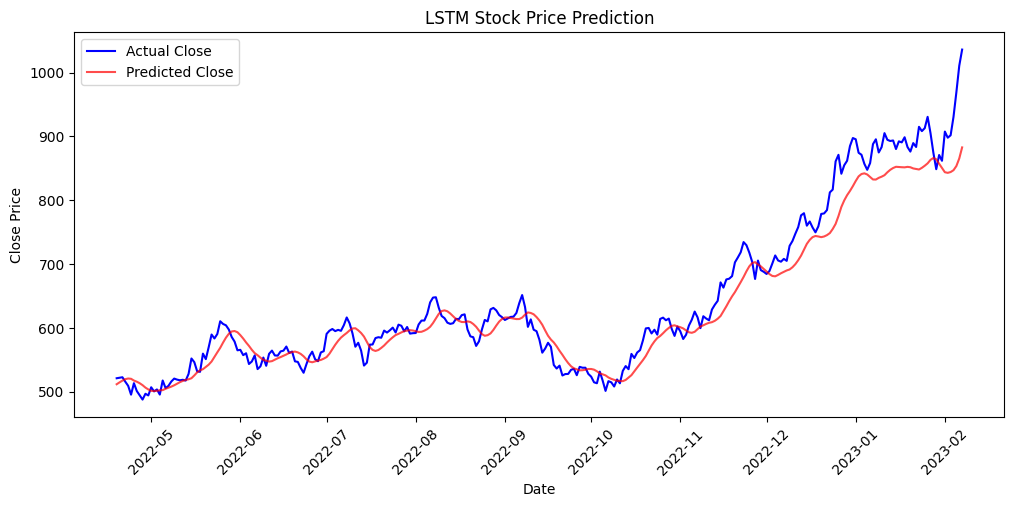

In [25]:
#plotting
plt.figure(figsize=(12,5))
plt.plot(df["date"][split_idx+n_steps:], y_test_inv, label="Actual Close", color="blue")
plt.plot(df["date"][split_idx+n_steps:], y_pred_inv, label="Predicted Close", color="red", alpha=0.7)
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("LSTM Stock Price Prediction")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [26]:
#Computing evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)
print(f"LSTM Test MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.4f}")

LSTM Test MAE: 23.53, RMSE: 31.92, R²: 0.9350


In [27]:
#saving model
model.save("lstm_close_model.h5")
import joblib
joblib.dump(scaler, "lstm_scaler.pkl")
print("LSTM model and scaler saved!")

LSTM model and scaler saved!


In [28]:
#forecast next 5 days
def forecast_next_days_lstm(df, n_days=5, n_steps=10):
    df_sorted = df.sort_values("date").reset_index(drop=True)
    close_prices = df_sorted["close"].values
    forecasted = []
    last_sequence = close_prices[-n_steps:]
    for day in range(1, n_days+1):
        seq_scaled = scaler.transform(last_sequence.reshape(-1,1)).reshape(1, n_steps, 1)
        pred_scaled = lstm_model.predict(seq_scaled, verbose=0)
        pred_close = scaler.inverse_transform(pred_scaled.reshape(-1,1))[0,0]
        last_date = df_sorted["date"].max()
        forecast_date = last_date + pd.Timedelta(days=day)
        forecasted.append({"date": forecast_date, "pred_close": pred_close})
        last_sequence = np.append(last_sequence[1:], pred_close)
    return pd.DataFrame(forecasted)

In [29]:
#run forecast
forecast_df = forecast_next_days_lstm(df, n_days=5, n_steps=10)
print(forecast_df)

        date  pred_close
0 2023-02-08  914.645447
1 2023-02-09  918.966736
2 2023-02-10  915.995422
3 2023-02-11  909.451843
4 2023-02-12  901.200134


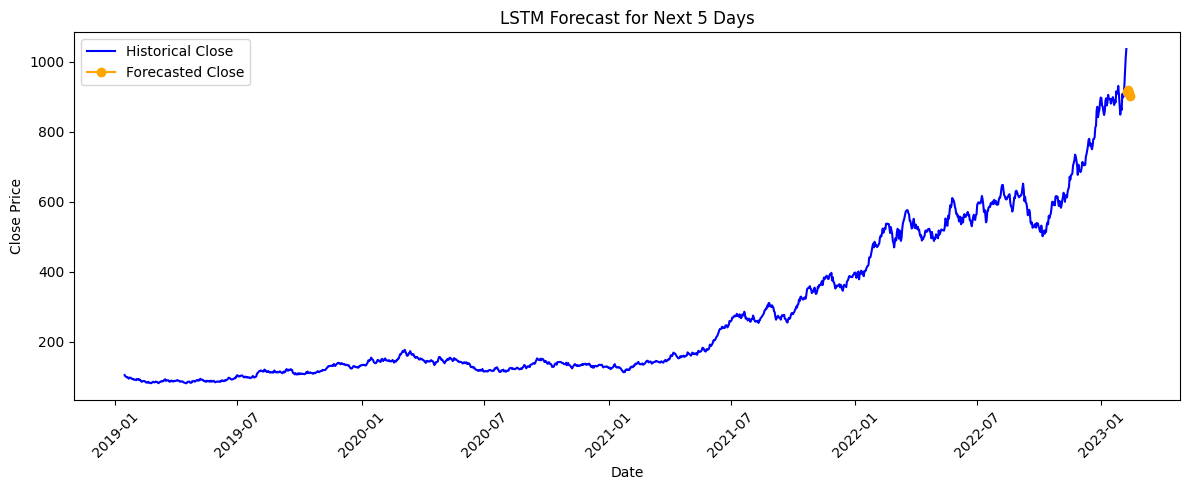

In [30]:
#plot forecast
plt.figure(figsize=(12,5))
plt.plot(df["date"], df["close"], label="Historical Close", color="blue")
plt.plot(forecast_df["date"], forecast_df["pred_close"], label="Forecasted Close", color="orange", marker='o')
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("LSTM Forecast for Next 5 Days")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()